In [1]:
# Imports

import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras.datasets import cifar10 # type: ignore
from tensorflow.keras.datasets import fashion_mnist # type: ignore
from keras.metrics import R2Score

2025-08-23 00:42:43.316709: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-23 00:42:43.317237: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-23 00:42:43.374530: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-23 00:42:44.483153: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

### Questão 1

Implemente uma rede perceptron de múltiplas camadas e utilize-a para aproximar as funções abaixo.  

a. f(x) = log10(x), onde 1 ≤ x ≤ 10

b. f(x) = 10x^5 + 5x^4 + 2x^3 – 0.5x^2 + 3x + 2, onde 0 ≤ x ≤ 5

Para cada função a ser aproximada, gere um conjunto de treinamento e um conjunto de testes. 

Nesses conjuntos, cada amostra deve ser representada da seguinte forma: x é a entrada e f(x) é a saída desejada - rótulo. Treine um perceptron de múltiplas camadas para que ele aprenda a aproximar a função a partir do conjunto de treinamento, e vá testando com o conjunto de validação.  

Apresente os gráficos das funções reais vs. funções aproximadas e as curvas de erro de treinamento e validação.

#### Item a)

In [2]:
# Data

f = lambda x: np.log10(x)
X = np.linspace(1, 10, 1000).reshape(-1, 1)
y = f(X)

X_max = max(X)
X_normalized = X/X_max
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_normalized, y, test_size=0.35, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

In [3]:
# Model

input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(100, activation="relu")(input_)
hidden2 = keras.layers.Dense(100, activation="relu")(hidden1)
hidden3 = keras.layers.Dense(100, activation="relu")(hidden2)
output = keras.layers.Dense(1, dtype="float64")(hidden3)

model = keras.Model(inputs=[input_], outputs=[output])
model.compile(loss="mse", optimizer="adam")
model.summary()

E0000 00:00:1755920565.217589  197762 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1755920565.220842  197762 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,501 (80.48 KB)

 Trainable params: 20,501 (80.48 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Train

history = model.fit(X_train, y_train, epochs=50, validation_data=(X_valid, y_valid))

# Prediction

y_pred = model.predict(X_test)

Epoch 1/50
 1/17 ━━━━━━━━━━━━━━━━━━━━ 12s 787ms/step - loss: 0.5997

2025-08-23 00:42:46.061939: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-23 00:42:46.092100: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2386 - val_loss: 0.0093
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0141 - val_loss: 0.0074
Epoch 3/50
 1/17 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0063

2025-08-23 00:42:46.314892: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-23 00:42:46.320362: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0069 - val_loss: 0.0074
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0050 - val_loss: 0.0055
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0044 - val_loss: 0.0053
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0042 - val_loss: 0.0049
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0040 - val_loss: 0.0046
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0037 - val_loss: 0.0041
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0034 - val_loss: 0.0038
Epoch 10/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0032 - val_loss: 0.0034
Epoch 11/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 12/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0024 - val_loss: 0.0024
Epoch 13/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0019 - val_loss: 0.0019
Epoch 14/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0015 - val_loss: 0.001

2025-08-23 00:42:51.320261: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-23 00:42:51.322874: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-23 00:42:51.360106: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-23 00:42:51.362996: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


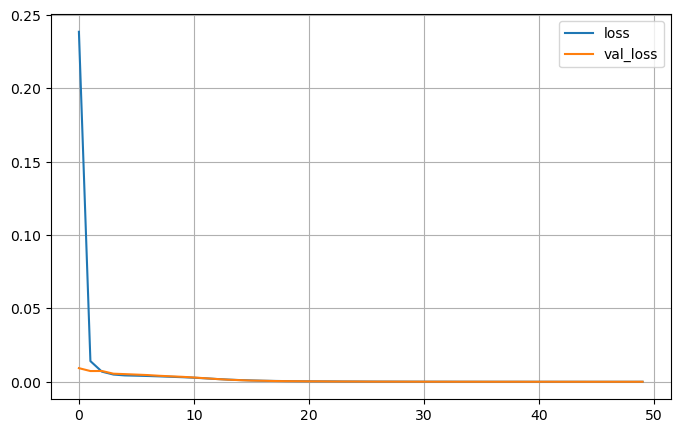

In [5]:
# Training Metrics

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

tf.Tensor(0.9990211, shape=(), dtype=float32)


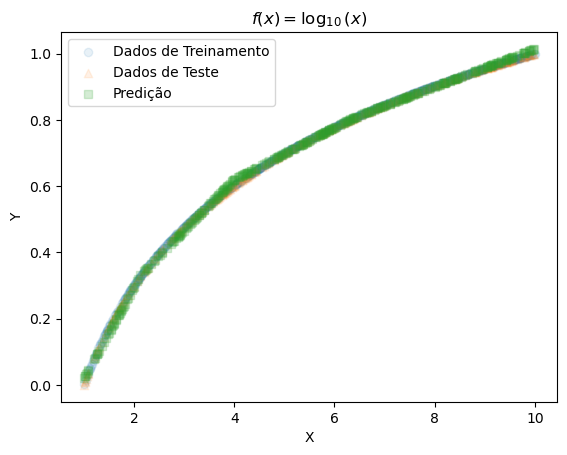

In [6]:
# Metrics

metric = keras.metrics.R2Score()
metric.update_state(y_test, y_pred)
result = metric.result()
print(result)

X_train_plot = X_train*X_max
X_test_plot = X_test*X_max

plt.figure()
plt.scatter(X_train_plot, y_train, alpha=0.1, label="Dados de Treinamento")
plt.scatter(X_test_plot, y_test, marker="^", alpha=0.1, label="Dados de Teste")
plt.scatter(X_test_plot, y_pred, marker="s", alpha=0.2, label="Predição")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title(r"$f(x) = \log _{10}(x)$");


#### Item b)

In [7]:
# Data

f = lambda x: 10*x**5 + 5*x**4 + 2*x**3 - 0.5*x**2 + 3*x + 2
X = np.linspace(0, 5, 1000).reshape(-1,1)
y = f(X)

X_max = max(X)
X_normalized = X/X_max
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_normalized, y, test_size=0.35, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

In [8]:
# Model

input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(200, activation="relu")(input_)
hidden2 = keras.layers.Dense(200, activation="relu")(hidden1)
hidden3 = keras.layers.Dense(200, activation="relu")(hidden2)
output = keras.layers.Dense(1, dtype="float64")(hidden3)

model = keras.Model(inputs=[input_], outputs=[output])
model.compile(loss="mse", optimizer="adam")
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 200)            │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,001 (317.20 KB)

 Trainable params: 81,001 (317.20 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train

history = model.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid))

# Prediction

y_pred = model.predict(X_test)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 117260216.0000

2025-08-23 00:42:52.931397: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-23 00:42:52.964134: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 112390688.0000 - val_loss: 105509112.0000
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 112318312.0000 - val_loss: 105359168.0000
Epoch 3/100
 1/17 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 77236824.0000

2025-08-23 00:42:53.192729: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-23 00:42:53.200586: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 112011576.0000 - val_loss: 104821152.0000
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 111071120.0000 - val_loss: 103324600.0000
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 108632992.0000 - val_loss: 99910136.0000
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 103926248.0000 - val_loss: 93428160.0000
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 95563592.0000 - val_loss: 83586104.0000
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 83866040.0000 - val_loss: 71144120.0000
Epoch 9/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 70703112.0000 - val_loss: 59474812.0000
Epoch 10/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 60693664.0000 - val_loss: 53530408.0000
Epoch 11/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 56640448.0000 - val_loss: 52055240.0000
Epoch 12/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 55544160.0000 - val_loss: 51096196.0000
Epoch 13/100


2025-08-23 00:43:05.600672: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-23 00:43:05.604027: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-23 00:43:05.641320: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-08-23 00:43:05.644477: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


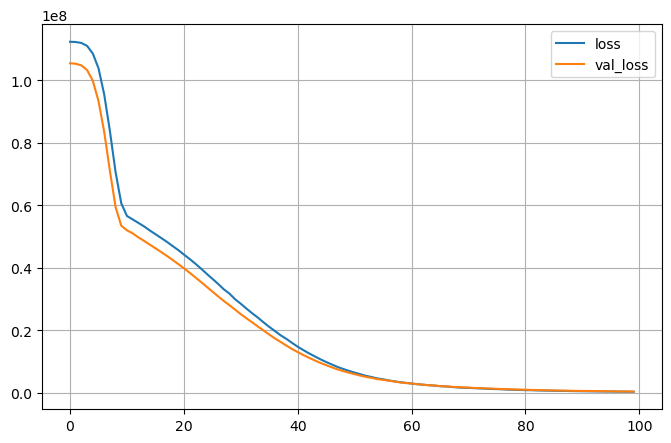

In [10]:
# Training Metrics

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

tf.Tensor(0.9946975, shape=(), dtype=float32)


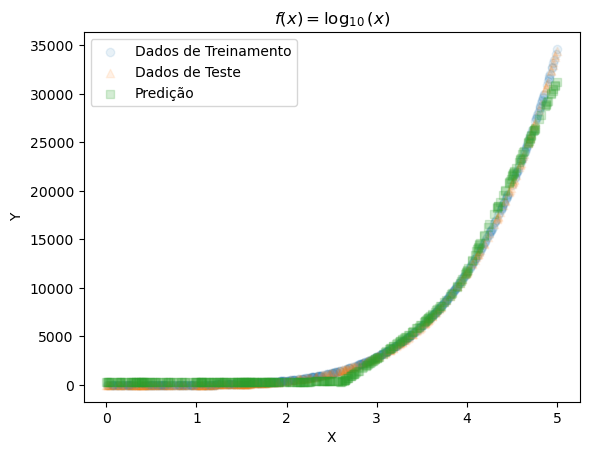

In [11]:
# Metrics

metric = keras.metrics.R2Score()
metric.update_state(y_test, y_pred)
result = metric.result()
print(result)

X_train_plot = X_train*X_max
X_test_plot = X_test*X_max

plt.figure()
plt.scatter(X_train_plot, y_train, alpha=0.1, label="Dados de Treinamento")
plt.scatter(X_test_plot, y_test, marker="^", alpha=0.1, label="Dados de Teste")
plt.scatter(X_test_plot, y_pred, marker="s", alpha=0.2, label="Predição")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title(r"$f(x) = \log _{10}(x)$");

### Questão 2

### Questão 3

In [12]:
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = cifar10.load_data()

print("CIFAR-10 Training data shape:", X_train_cifar.shape)
print("CIFAR-10 Training labels shape:", y_train_cifar.shape)
print("CIFAR-10 Test data shape:", X_test_cifar.shape)
print("CIFAR-10 Test labels shape:", y_test_cifar.shape)

CIFAR-10 Training data shape: (50000, 32, 32, 3)
CIFAR-10 Training labels shape: (50000, 1)
CIFAR-10 Test data shape: (10000, 32, 32, 3)
CIFAR-10 Test labels shape: (10000, 1)


### Questão 4

In [13]:
(X_train_fashion, y_train_fashion), (X_test_fashion, y_test_fashion) = fashion_mnist.load_data()

print("Fashion-MNIST Training data shape:", X_train_fashion.shape)
print("Fashion-MNIST Training labels shape:", y_train_fashion.shape)
print("Fashion-MNIST Test data shape:", X_test_fashion.shape)
print("Fashion-MNIST Test labels shape:", y_test_fashion.shape)

Fashion-MNIST Training data shape: (60000, 28, 28)
Fashion-MNIST Training labels shape: (60000,)
Fashion-MNIST Test data shape: (10000, 28, 28)
Fashion-MNIST Test labels shape: (10000,)


### Questão 5